# 2. Python

We will be using the following PyData Tools for the Exercises:

* Pandas: <https://pandas.pydata.org/>
* NumPy: <https://numpy.org/>
* Scikit-Learn: <https://scikit-learn.org/>

This tutorial is based on:


* Wes McKinney, Python for Data Analysis, 2nd Edition, <https://github.com/wesm/pydata-book>
* <https://github.com/jonathanrocher/pandas_tutorial/blob/master/analyzing_and_manipulating_data_with_pandas_manual.pdf>




# 2.1 Tutorial

Follow and execute the Examples Notebooks in the Folder:

* Python and iPython Introduction
* Python Data Structures
* Pandas Tour
* NumPy Tour

# 2.2 Practical Exercise

Use the Iris dataset from the scikit-learn Dataset API to solve the following tasks:
1. How many flowers of each kind are in the dataset?
2. What is the average and standard deviation of all four attributes for all flowers and per flower group?
3. Plot the results!

In [1]:
%matplotlib inline
from sklearn import linear_model, datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [2]:
iris = datasets.load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
iris_df["target_name"]=iris['target_names'][iris_df['target']]
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   target_name        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
iris_df.groupby('target_name').aggregate({'target_name':'count', })

,target_name
target_name,
setosa,50
versicolor,50
virginica,50


In [13]:
#A1
flower_counts = iris_df['target_name'].value_counts()
print("--- Number of flowers per species ---")
print(flower_counts)

--- Number of flowers per species ---
target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [14]:
#A2

features = iris.feature_names

# Values for all flowers combined
print("\n--- Overall Average (All Flowers) ---")
print(iris_df[features].mean())

print("\n--- Overall Standard Deviation (All Flowers) ---")
print(iris_df[features].std())

# Values grouped by flower species
print("\n--- Average and Standard Deviation per Group ---")
group_stats = iris_df.groupby('target_name')[features].agg(['mean', 'std'])
print(group_stats)


--- Overall Average (All Flowers) ---
sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

--- Overall Standard Deviation (All Flowers) ---
sepal length (cm)    0.828066
sepal width (cm)     0.435866
petal length (cm)    1.765298
petal width (cm)     0.762238
dtype: float64

--- Average and Standard Deviation per Group ---
            sepal length (cm)           sepal width (cm)            \
                         mean       std             mean       std   
target_name                                                          
setosa                  5.006  0.352490            3.428  0.379064   
versicolor              5.936  0.516171            2.770  0.313798   
virginica               6.588  0.635880            2.974  0.322497   

            petal length (cm)           petal width (cm)            
                         mean       std             mean       std  
target_name                     

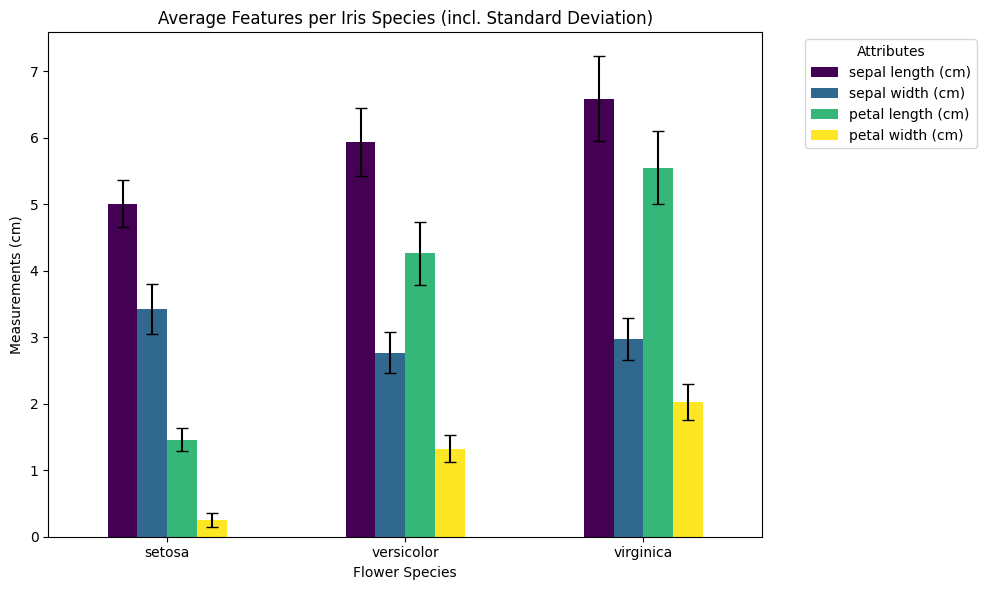

In [15]:
#A3
means = iris_df.groupby('target_name')[features].mean()
stds = iris_df.groupby('target_name')[features].std()

fig, ax = plt.subplots(figsize=(10, 6))
means.plot(kind='bar', yerr=stds, ax=ax, capsize=4, rot=0, colormap='viridis')

plt.title('Average Features per Iris Species (incl. Standard Deviation)')
plt.ylabel('Measurements (cm)')
plt.xlabel('Flower Species')
plt.legend(title='Attributes', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()